# BABA NN

In [2]:
import numpy as np
import tensorflow as tf
print(tf.__version__) 
from matplotlib import pyplot as plt
import pandas as pd

2.21.0


In [13]:
DATA_DIR = "../data"

BATCH_SIZE = 32

### Build model function

In [17]:
def build_model(config_size, hidden_nodes):
    l2 = 1e-4  # regularization strength λ
    x = tf.keras.Input((config_size,))
    y = tf.keras.layers.Dense(hidden_nodes, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    z = tf.keras.layers.Dense(1, activation='sigmoid')(y)
    model = tf.keras.Model(inputs=x, outputs=z)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    return model

### NN with 3 nodes

In [66]:
data = np.load("../data/L30_ising.npz")
"""split data into input and output"""
T = data["temperatures"]
T_c = 2 / np.log(1 + np.sqrt(2))        
labels = (T > T_c).astype(int)      #create labels from temperature
configs = data["spins"]

"""split into training, validation and test data"""
train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
train_label, val_label, test_label = np.split(labels, [80000, 90000])
train_T, val_T, test_T = np.split(T, [80000, 90000])
#print(train_conf.shape)

model3 = build_model(900, 3)

w_init, b_init = model3.layers[1].get_weights()

history = model3.fit(
    train_conf,
    train_label,
    validation_data = (val_conf, val_label),
    batch_size = 256,
    epochs = 200
)

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │         2,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,707 (10.57 KB)

 Trainable params: 2,707 (10.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.6674 - val_loss: 0.8485
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 0.6103 - val_loss: 0.8628
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.5635 - val_loss: 0.8026
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.5085 - val_loss: 0.7091
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.4504 - val_loss: 0.5858
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 0.3952 - val_loss: 0.4700
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 0.3468 - val_loss: 0.3733
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.3060 - val_loss: 0.3022
Epoch 9/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 0.2719 - val_loss: 0.2456
Epoch 10/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.2435 - val_loss: 0.2047
Epoch 11/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.2195 - val_loss: 0.1745
Epoch 12/200
313/31

evaluation

In [63]:
model3.evaluate(test_conf, test_label, batch_size=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - loss: 0.0141


0.01408347487449646

### Plots similar to the paper

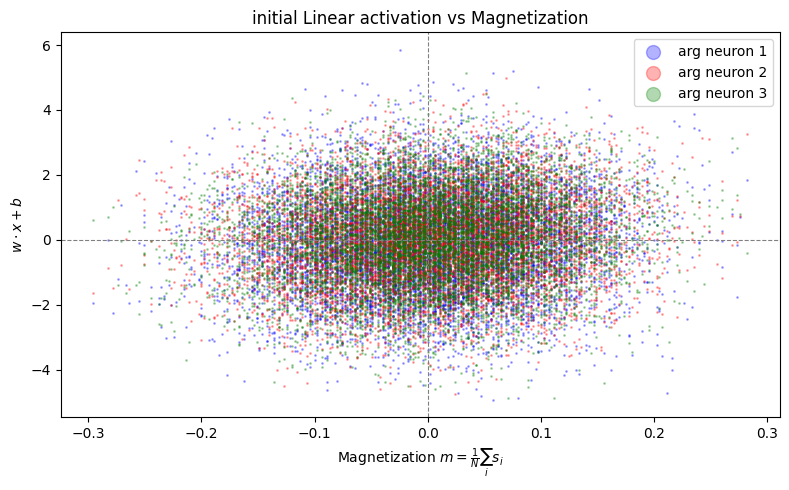

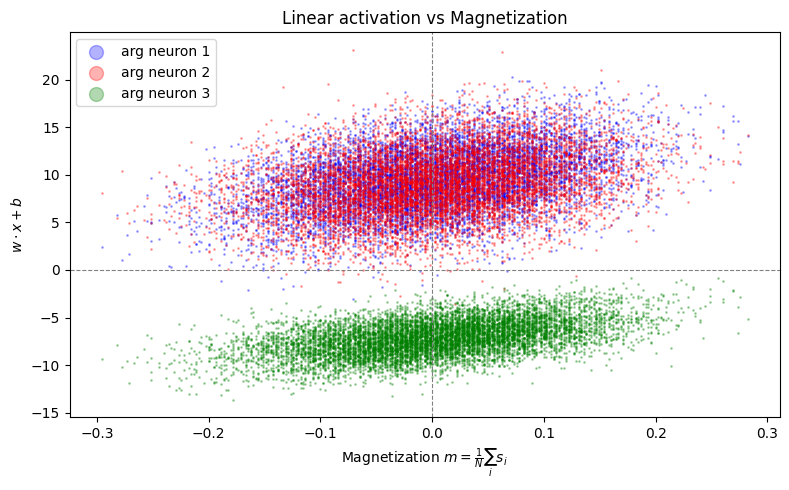

In [67]:
m = test_conf.mean(axis=1)
w, b = model3.layers[1].get_weights()
init_hidden_args = test_conf @ w_init + b_init
hidden_args = test_conf @ w + b
#print(hidden_args[:,0].shape)

plt.figure(figsize=(8, 5))
plt.scatter(m, init_hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("initial Linear activation vs Magnetization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(m, hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("Linear activation vs Magnetization")
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step


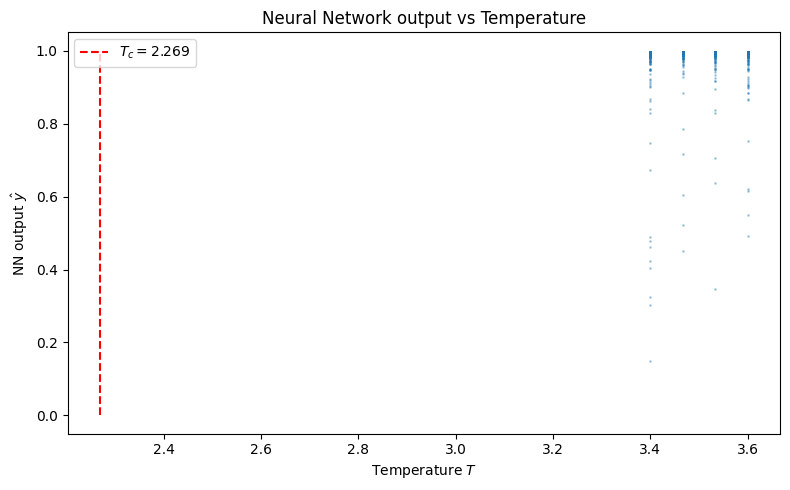

In [70]:
nn_predict = model3.predict(test_conf)

plt.figure(figsize=(8, 5))
plt.scatter(test_T, nn_predict, s=1, alpha=0.3)
#plt.plot(T, nn_predict)
plt.vlines(T_c,  ymin = 0, ymax = 1, color='red', linestyle='--', linewidth=1.5, label=f"$T_c = {T_c:.3f}$")
plt.xlabel("Temperature $T$")
plt.ylabel("NN output $\\hat{y}$")
plt.title("Neural Network output vs Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### 100 Nodes NN